# Why does peak surface flux differ so much across intervention sites?

Investigation into the four intervention sites (Japan J, Vancouver Island V, Baja California B, Ecuador E), all built from the same recipe in `make_tracer_surface_flux.ipynb`: a Gaussian with std dev 300 km, masked to ocean points, rescaled to preserve total integrated magnitude.

**Peak surface flux differs by up to ~1.8x across sites** for the same total released mass (e.g. 44.6, 27.2, 24.8, 24.6 mol/m2/yr at V, E, J, B for the 1 Tmol experiments), despite the same nominal 300 km Gaussian. This notebook reproduces the exact `make_tracer_surface_flux.ipynb` pipeline and decomposes this into two multiplicative effects: (a) grid resolution / mass conservation on a non-uniform grid, and (b) land masking and redistribution over the remaining ocean cells.

In [10]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import gcm_filters

from roms_tools import Grid
from roms_tools.vertical_coordinate import compute_depth

In [11]:
ds_grid = xr.open_dataset("INPUT/pacmed12_grd.nc")

# Same locations and grid indices as in make_tracer_surface_flux.ipynb
locations = {
    "Japan": (710, 459),
    "Vancouver Island": (855, 1135),
    "Baja California": (650, 1290),
    "Ecuador": (490, 1640),
}

## 1. Grid-resolution effect (mass conservation on a non-uniform grid)

We reproduce the exact `create_gaussian` pipeline from `make_tracer_surface_flux.ipynb`: a `gcm_filters` Gaussian filter with `filter_scale` (in grid cells) calibrated once from the **domain-mean** grid spacing `dx`. But `pacmed12_grd.nc` is regular in longitude/latitude, so physical cell size shrinks toward the poles (~cos(latitude)). A fixed number of grid cells therefore spans a different physical distance at each site.

Here we isolate this effect on its own by applying the filter **without any land mask** (`wet_mask` is all-ocean either way — the real land mask is only applied afterwards in `create_gaussian`, in Section 2). This step alone already conserves the released mass (`unmasked_mass ≈ 1` for every site, since the filter conserves total mass by construction) while letting the peak amplitude vary with the local grid spacing.

In [12]:
# Exact filter setup from make_tracer_surface_flux.ipynb
area = 1 / (ds_grid.pm * ds_grid.pn)
dx_domain_mean = (((1 / ds_grid.pm).mean() + (1 / ds_grid.pn).mean()) / 2).item()
all_ocean_mask = xr.ones_like(ds_grid.mask_rho)

std = 300000  # 300 km
filter_scale = std / dx_domain_mean * np.sqrt(12)

gaussian_filter = gcm_filters.Filter(
    filter_scale=filter_scale,
    dx_min=1,
    filter_shape=gcm_filters.FilterShape.GAUSSIAN,
    grid_type=gcm_filters.GridType.REGULAR_WITH_LAND_AREA_WEIGHTED,
    grid_vars={"wet_mask": all_ocean_mask, "area": area},
)

A_full = float(area.sum().values)  # total domain area (land + ocean), used in Section 2
print(f"Domain-mean dx = {dx_domain_mean/1000:.2f} km  ->  filter_scale = {filter_scale:.2f} grid cells")

Domain-mean dx = 10.97 km  ->  filter_scale = 94.70 grid cells


In [13]:
def make_point_source(eta, xi):
    """Unit-mass point source: delta[eta,xi] = 1/area[eta,xi], so sum(delta*area) = 1."""
    delta = xr.zeros_like(ds_grid["mask_rho"]).astype(float)
    delta[eta, xi] = 1 / area[eta, xi]
    return delta

unmasked = {}
for name, (eta, xi) in locations.items():
    delta = make_point_source(eta, xi)
    smooth = gaussian_filter.apply(delta, dims=["eta_rho", "xi_rho"])
    unmasked[name] = smooth

rows = []
for name, (eta, xi) in locations.items():
    local_dx = float((1 / ds_grid.pm).isel(eta_rho=eta, xi_rho=xi))
    peak = float(unmasked[name][eta, xi].values)
    mass = float((unmasked[name] * area).sum().values)
    sigma_eff_km = np.sqrt(1 / (2 * np.pi * peak)) / 1000  # invert peak = 1/(2*pi*sigma^2)
    rows.append((name, local_dx / 1000, peak, mass, sigma_eff_km))

print(f"{'Site':18s} {'local dx (km)':>14s} {'unmasked peak (1/m2)':>22s} {'mass (should be 1)':>20s} {'sigma_eff (km)':>15s}")
for name, dxkm, peak, mass, sig in rows:
    print(f"{name:18s} {dxkm:14.1f} {peak:22.4e} {mass:20.6f} {sig:15.1f}")

Site                local dx (km)   unmasked peak (1/m2)   mass (should be 1)  sigma_eff (km)
Japan                        11.3             1.6691e-12             1.000000           308.8
Vancouver Island              9.7             2.2555e-12             1.000000           265.6
Baja California              11.8             1.5291e-12             1.000000           322.6
Ecuador                      12.5             1.3722e-12             1.000000           340.6


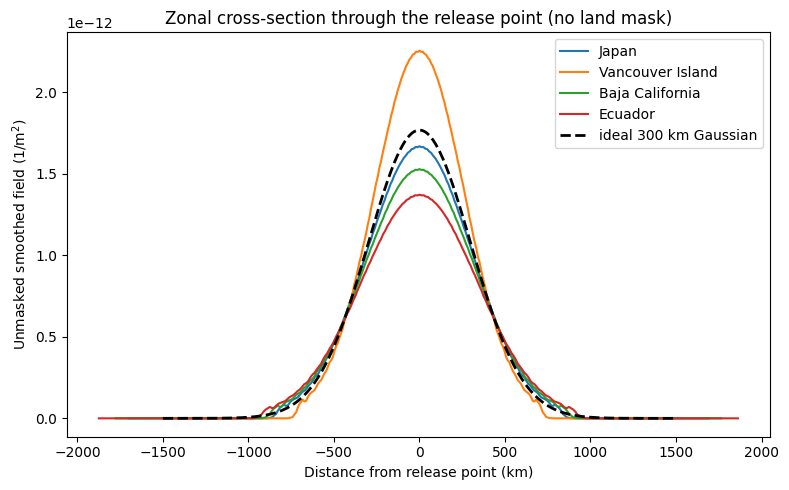

In [5]:
half_width_pts = 150

fig, ax = plt.subplots(figsize=(8, 5))
for name, (eta, xi) in locations.items():
    xi_slice = slice(xi - half_width_pts, xi + half_width_pts)
    profile = unmasked[name].isel(eta_rho=eta, xi_rho=xi_slice).values
    dx_local = (1 / ds_grid.pm).isel(eta_rho=eta, xi_rho=xi_slice).values
    dist_km = np.cumsum(dx_local) / 1000
    dist_km -= dist_km[half_width_pts]  # center on the release point
    ax.plot(dist_km, profile, label=name)

# Reference: ideal continuous 2D Gaussian with sigma=300 km, mass=1, evaluated along a cross-section
dist_ref = np.linspace(-1500, 1500, 400) * 1000
sigma_ref = 300000
ref = 1 / (2 * np.pi * sigma_ref**2) * np.exp(-dist_ref**2 / (2 * sigma_ref**2))
ax.plot(dist_ref / 1000, ref, "k--", label="ideal 300 km Gaussian", lw=2)

ax.set_xlabel("Distance from release point (km)")
ax.set_ylabel("Unmasked smoothed field (1/m$^2$)")
ax.set_title("Zonal cross-section through the release point (no land mask)")
ax.legend()
plt.tight_layout()
fig.savefig("figures/flux_gaussian_cross_sections.png", dpi=300, bbox_inches="tight")

## 2. Land masking and redistribution

`create_gaussian` now zeros the unmasked field over land and renormalizes:

```python
delta_smooth = delta_smooth.where(ds_grid.mask_rho, 0.0)
integral = (delta_smooth * area).sum(dim=[...]) / area.sum(dim=[...])
delta_smooth = delta_smooth / integral
```

The key, non-obvious point: `area.sum()` in the denominator is the **total domain area** (land + ocean, everywhere), not just the local footprint or the ocean-only area. Write `retained_frac` = the fraction of the unmasked Gaussian's mass that lands on ocean cells, so the ocean-retained mass is `retained_frac * unmasked_mass ≈ retained_frac` (since `unmasked_mass ≈ 1`, Section 1). Then:

```
integral = retained_frac * A_full_area^-1        (since ocean_mass = retained_frac, and integral = ocean_mass / A_full)
final_field = masked_field / integral = masked_field * A_full / retained_frac
```

Two consequences:
1. The **total mass of the final field is exactly `A_full` at every site**, regardless of `retained_frac` — masking out land never changes the total released mass, by construction.
2. Because that fixed total mass must now fit into a smaller ocean footprint when `retained_frac` is small, the peak gets an extra boost of `1/retained_frac` on top of the grid-resolution effect from Section 1.

In [6]:
def create_gaussian(smooth_unmasked):
    """Exact land-masking + renormalization step from make_tracer_surface_flux.ipynb."""
    masked = smooth_unmasked.where(ds_grid.mask_rho, 0.0)
    integral = (masked * area).sum(dim=["eta_rho", "xi_rho"]) / area.sum(dim=["eta_rho", "xi_rho"])
    return masked / integral

final = {}
retained_frac = {}
for name, (eta, xi) in locations.items():
    masked = unmasked[name].where(ds_grid.mask_rho, 0.0)
    ocean_mass = float((masked * area).sum().values)
    unmasked_mass = float((unmasked[name] * area).sum().values)
    retained_frac[name] = ocean_mass / unmasked_mass
    final[name] = create_gaussian(unmasked[name])

print(f"{'Site':18s} {'retained ocean fraction':>24s} {'final total mass':>18s} {'A_full (should match)':>22s}")
for name, (eta, xi) in locations.items():
    total_mass_final = float((final[name] * area).sum().values)
    print(f"{name:18s} {retained_frac[name]:24.3f} {total_mass_final:18.4e} {A_full:22.4e}")

Site                retained ocean fraction   final total mass  A_full (should match)
Japan                                 0.793         2.1621e+14             2.1621e+14
Vancouver Island                      0.596         2.1621e+14             2.1621e+14
Baja California                       0.732         2.1621e+14             2.1621e+14
Ecuador                               0.595         2.1621e+14             2.1621e+14


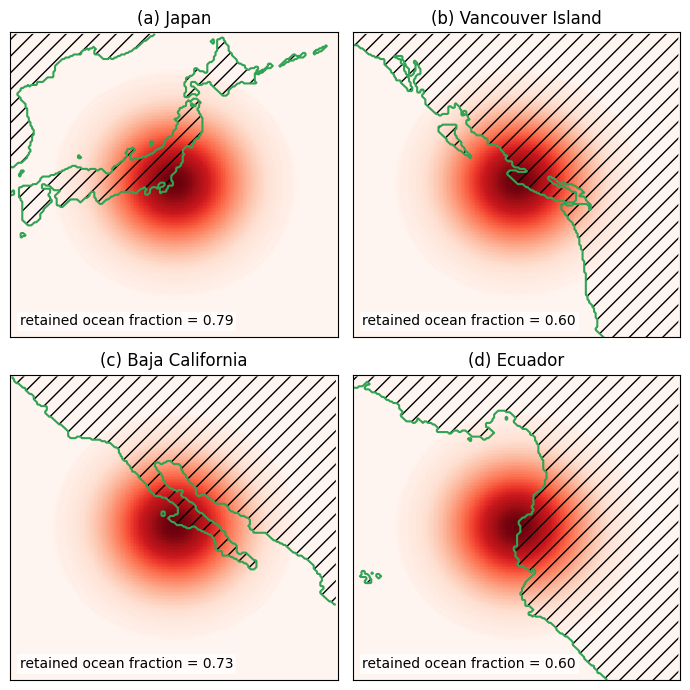

In [7]:
# Zoom on the raw (unmasked) footprint and the land mask around each release point,
# to visualize how much of each Gaussian actually falls on land.
zoom_pts = 100
fig, axs = plt.subplots(2, 2, figsize=(7, 7))

axs_f = axs.flatten()
labels = ["(a)", "(b)", "(c)", "(d)"]
          
for i, (name, (eta, xi)) in enumerate(locations.items()):
    eta_slice = slice(eta - zoom_pts, eta + zoom_pts)
    xi_slice = slice(xi - zoom_pts, xi + zoom_pts)
    field = unmasked[name].isel(eta_rho=eta_slice, xi_rho=xi_slice)
    land = (~ds_grid.mask_rho.astype(bool)).isel(eta_rho=eta_slice, xi_rho=xi_slice)

    axs_f[i].pcolormesh(field.values, cmap="Reds")
    axs_f[i].contourf(land.values.astype(float), levels=[0.5, 1.5], colors=["none"], hatches=["//"])
    axs_f[i].contour(land.values.astype(float), levels=[0.5], colors="#31a354", linewidths=1.5)
    axs_f[i].set_title(f"{labels[i]} {name}")
    axs_f[i].set_xticks([])
    axs_f[i].set_yticks([])
    axs_f[i].text(
        0.03, 0.03, f"retained ocean fraction = {retained_frac[name]:.2f}",
        transform=axs_f[i].transAxes, ha="left", va="bottom", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    )
plt.tight_layout()
fig.savefig("figures/flux_land_mask_footprints.png", dpi=300, bbox_inches="tight")

## 3. Putting it together: decomposing the total amplification

`final_peak(site) = unmasked_peak(site) * A_full / retained_frac(site)`. Take Japan as a reference and split the ratio into a **grid-resolution factor** (`unmasked_peak(site)/unmasked_peak(JP)`) and a **land factor** (`retained_frac(JP)/retained_frac(site)`); their product should reproduce the actual final-peak ratio, and — converted to mol/m2/yr for the 1 Tmol amplitude — the paper's reported peak fluxes (44.6, 27.2, 24.8, 24.6 mol/m2/yr at V, E, J, B).

In [14]:
# Same amplitude scaling as make_tracer_surface_flux.ipynb: amplitude "8" = 1 Tmol
norm = 1 / 5.791 / 10**20
factor_1Tmol = 10**15 * norm

reference = "Japan"
unmasked_peak = {name: float(unmasked[name][eta, xi].values) for name, (eta, xi) in locations.items()}

reported_peak_flux = {  # mol/m2/yr, from the paper, 1 Tmol experiments
    "Japan": 24.8, "Vancouver Island": 44.6, "Baja California": 24.6, "Ecuador": 27.2,
}

print(f"{'Site':18s} {'grid factor':>12s} {'land factor':>12s} {'product':>10s} "
      f"{'predicted flux':>15s} {'actual flux':>12s} {'reported':>10s}")
for name, (eta, xi) in locations.items():
    grid_factor = unmasked_peak[name] / unmasked_peak[reference]
    land_factor = retained_frac[reference] / retained_frac[name]
    product = grid_factor * land_factor

    actual_peak = float(final[name][eta, xi].values)
    actual_flux = actual_peak * factor_1Tmol / 1000 * 3600 * 24 * 365.25  # mmol/m2/s -> mol/m2/yr
    predicted_flux = reported_peak_flux[reference] * product

    print(f"{name:18s} {grid_factor:12.3f} {land_factor:12.3f} {product:10.3f} "
          f"{predicted_flux:15.2f} {actual_flux:12.2f} {reported_peak_flux[name]:10.2f}")

Site                grid factor  land factor    product  predicted flux  actual flux   reported
Japan                     1.000        1.000      1.000           24.80        24.81      24.80
Vancouver Island          1.351        1.331      1.798           44.60        44.61      44.60
Baja California           0.916        1.083      0.992           24.60        24.61      24.60
Ecuador                   0.822        1.332      1.095           27.16        27.17      27.20


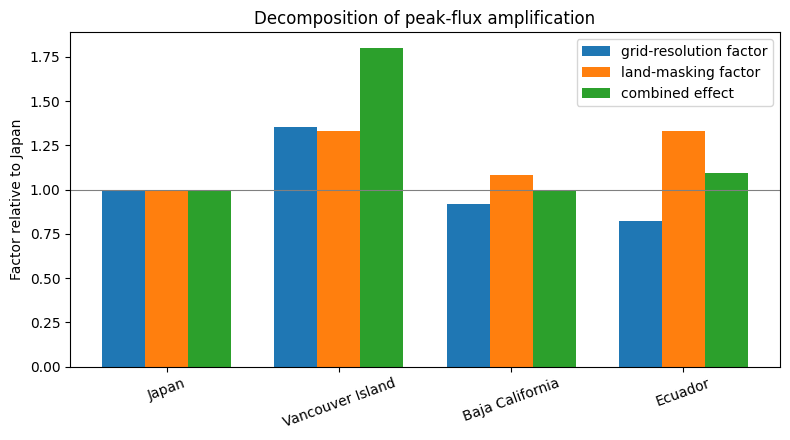

In [15]:
names = list(locations.keys())
grid_factors = [unmasked_peak[n] / unmasked_peak[reference] for n in names]
land_factors = [retained_frac[reference] / retained_frac[n] for n in names]
combined_factors = [g * l for g, l in zip(grid_factors, land_factors)]

x = np.arange(len(names))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width, grid_factors, width, label="grid-resolution factor")
ax.bar(x, land_factors, width, label="land-masking factor")
ax.bar(x + width, combined_factors, width, label="combined effect")
ax.axhline(1.0, color="gray", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20)
ax.set_ylabel(f"Factor relative to {reference}")
ax.set_title("Decomposition of peak-flux amplification")
ax.legend()
plt.tight_layout()
fig.savefig("figures/flux_amplification_decomposition.png", dpi=300, bbox_inches="tight")